# Atmosphere buffers: what named dimensions change

This notebook follows one frozen atmosphere cube into optical fields, instantaneous PSFs and an integrated exposure. The explicit loop and latent batch consume **exactly the same samples**. Agreement is assessed on complex fields and raw detector counts, not just pictures.

The main example uses independent Kolmogorov screens (an ensemble, not a frozen-flow time model). The final section separately checks a correlated injected backend. All numbers and figures below are computed by executing the notebook.

## 1. Experiment and the two propagation paths

A 0.8 m circular pupil is sampled on 64×64 pixels. The MFT focal plane samples the diffraction scale λf/D with four pixels so the PSF core and halo are visible. We freeze 24 OPD screens once. The time axis assigns 10 ms quadrature weights; total exposure is 0.24 s.

Only the explicit reference loops over time. The batch passes the full labelled tensor through the same optical chain once. Static DM, Fresnel and ZELDA variants are checked as well.

In [1]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from IPython.display import display, HTML
from html import escape
import torch
from fiatlux import (
    CircularAperture, Grid, Spectrum, PhotometricBand, PlaneWave, FieldDimension, SerialSystem,
    FFTPropagator, MFTPropagator, ZeldaMask, ZeldaStop, DeformableMirror,
    ActuatorGrid, ZernikeBasis, KolmogorovAtmosphereModel, Detector,
    ExposureAccumulator, Atmosphere, FatmossAtmosphereModel,
)

torch.set_num_threads(1)
dtype = torch.float64
grid = Grid(64, 64, .02, .02, dtype=dtype)
T, dt, diameter = 24, .01, .8
focal_grid = Grid(96, 96, 1.1e-6*2/diameter/4, 1.1e-6*2/diameter/4, dtype=dtype)
mono = PlaneWave(Spectrum(0, PhotometricBand.HCM2, 1, dtype=dtype)).generate_field(grid)
poly = PlaneWave(Spectrum(0, PhotometricBand.HCM2, 3, dtype=dtype)).generate_field(grid)
pupil = CircularAperture(grid, radius=diameter/2)
mono, poly = pupil.apply(mono), pupil.apply(poly)
model = KolmogorovAtmosphereModel(grid, .12, seed=902)
opd = model.sample_opd_many(T)  # Freeze once; both paths use exactly these values.
time = FieldDimension('time', T, torch.arange(T, dtype=dtype)*dt,
                      's', torch.full((T,), dt, dtype=dtype))
dm = DeformableMirror(grid, ActuatorGrid(3, 3, .1), grid, ZernikeBasis(grid, 3))
dm.commands = torch.tensor([20e-9, -10e-9, 5e-9], dtype=dtype)
cases = [
    ('FFT Fraunhofer', mono, [FFTPropagator(2.)]),
    ('MFT monochromatic Fraunhofer', mono, [MFTPropagator(2., focal_grid)]),
    ('MFT polychromatic Fraunhofer', poly, [MFTPropagator(2., focal_grid)]),
    ('MFT Fresnel', mono, [MFTPropagator(output_grid=focal_grid, propagation='fresnel', distance=2.)]),
    ('ZELDA', mono, [MFTPropagator(2., focal_grid), ZeldaMask(focal_grid, 1e-6, 2.5e-7),
                     MFTPropagator(-2., grid), ZeldaStop(grid, .25)]),
    ('Static DM + atmosphere', mono, [dm, FFTPropagator(2.)]),
]


def errors(actual, expected):
    delta = (actual-expected).abs()
    # Raw maximum relative error can be sensitive to near-zero samples; retain
    # the absolute error alongside it. This does not rescale either result.
    return {'max_absolute': float(delta.max()),
            'max_relative': float((delta/expected.abs().clamp_min(torch.finfo(dtype).tiny)).max()),
            'rms': float(delta.square().mean().sqrt())}


rows = []
images = {}
results = {}
with torch.no_grad():
    for name, source_field, elements in cases:
        system = SerialSystem(elements)
        loop = torch.stack([system.run_field(source_field.apply_opd(screen)).final_field.complex_amplitude for screen in opd])
        buffer = source_field.apply_opd(opd, dimensions=(time,))
        batched = system.run_field(buffer).final_field
        torch.testing.assert_close(batched.complex_amplitude, loop, rtol=1e-11, atol=1e-8)
        expected = (loop.abs().square().sum(-3)*dt).sum(0)*batched.grid.dx*batched.grid.dy
        detector = Detector(batched.grid, exposure_time=T*dt)
        one_shot = detector.acquire(batched, integrate_over='time')
        accumulator = ExposureAccumulator(detector)
        for start, stop in [(0, 5), (5, 13), (13, T)]:
            accumulator.add(batched.slice('time', start, stop))
        chunked = accumulator.finish()
        torch.testing.assert_close(one_shot, expected, rtol=1e-11, atol=1e-8)
        torch.testing.assert_close(chunked, expected, rtol=1e-11, atol=1e-8)
        images[name] = one_shot
        results[name] = dict(field=batched, loop=loop, expected=expected, counts=one_shot, chunked=chunked)
        rows.append({'case': name, 'opd_shape': list(opd.shape),
                     'input_field_shape': list(buffer.complex_amplitude.shape),
                     'output_field_shape': list(batched.complex_amplitude.shape), 'field': errors(batched.complex_amplitude, loop),
                     'exposure': errors(one_shot, expected), 'chunked': errors(chunked, expected)})

In [2]:
def table(headers, rows):
    body = '<tr>' + ''.join(f'<th>{escape(str(h))}</th>' for h in headers) + '</tr>'
    for row in rows:
        body += '<tr>' + ''.join(f'<td>{escape(str(v))}</td>' for v in row) + '</tr>'
    display(HTML('<table style="border-collapse:collapse;text-align:right">' + body + '</table>'))

def extent(g, unit=1):
    return [(float(g.x[0])-g.dx/2)/unit, (float(g.x[-1])+g.dx/2)/unit,
            (float(g.y[0])-g.dy/2)/unit, (float(g.y[-1])+g.dy/2)/unit]

def array(t):
    return t.detach().cpu().numpy()

main = results['MFT monochromatic Fraunhofer']
field = main['field']
area = field.grid.dx*field.grid.dy
rates = field.intensity().sum(-3)*area
mean_rate = main['counts']/(T*dt)
active = mono.intensity().sum(0)>0
rms_nm = opd[:, active].std(dim=-1, correction=0)*1e9
table(['Quantity','Value'], [
    ['Pupil diameter / sampling', f'{diameter} m / {grid.dx} m'],
    ['Wavelength', '1.1 µm (polychromatic cases: 1.075–1.125 µm)'],
    ['Atmosphere', 'Independent Kolmogorov screens; r0=0.12 m at 500 nm; seed=902'],
    ['Samples / cadence / exposure', f'{T} / {dt} s / {T*dt:.2f} s'],
    ['OPD → input Field → propagated Field', f'{tuple(opd.shape)} → {(T,1,64,64)} → {tuple(field.complex_amplitude.shape)}'],
    ['OPD RMS across the pupil', f'{rms_nm.min():.1f}–{rms_nm.max():.1f} nm'],
    ['Detector', 'QE=1; no photon, dark or read noise; no digitization'],
])

Quantity,Value
Pupil diameter / sampling,0.8 m / 0.02 m
Wavelength,1.1 µm (polychromatic cases: 1.075–1.125 µm)
Atmosphere,Independent Kolmogorov screens; r0=0.12 m at 500 nm; seed=902
Samples / cadence / exposure,24 / 0.01 s / 0.24 s
OPD → input Field → propagated Field,"(24, 64, 64) → (24, 1, 64, 64) → (24, 1, 96, 96)"
OPD RMS across the pupil,123.0–266.5 nm
Detector,"QE=1; no photon, dark or read noise; no digitization"


## 2. Inspect the input data

These OPD frames share the same colour limits. Only the illuminated pupil is shown; the rest of each screen is masked for display. RMS is measured inside that pupil.

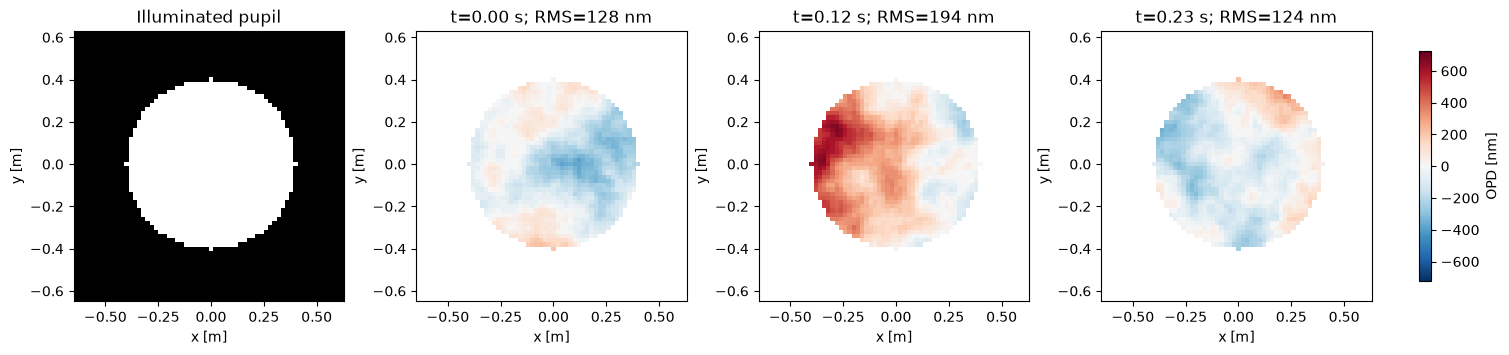

In [3]:
indices = [0, T//2, T-1]
fig, axes = plt.subplots(1, 4, figsize=(15,3.5), constrained_layout=True)
axes[0].imshow(array(active), origin='lower', extent=extent(grid), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Illuminated pupil')
limit = float(opd[:,active].abs().max()*1e9)
for ax,i in zip(axes[1:],indices):
    im=ax.imshow(np.ma.masked_where(~array(active), array(opd[i]*1e9)), origin='lower',
                 extent=extent(grid), cmap='RdBu_r', vmin=-limit, vmax=limit)
    ax.set_title(f't={i*dt:.2f} s; RMS={rms_nm[i]:.0f} nm')
fig.colorbar(im, ax=list(axes[1:]), label='OPD [nm]', shrink=.8)
for ax in axes: ax.set(xlabel='x [m]',ylabel='y [m]')
plt.show()

## 3. Instantaneous images and the integrated exposure

All panels use one logarithmic colour scale in photons/s/pixel. The exposure is divided by its duration **only for this rate comparison**. Neither propagation result is renormalized. Averaging independent screens smooths the realization-dependent speckle pattern; 24 frames are an illustration, not a convergence guarantee.

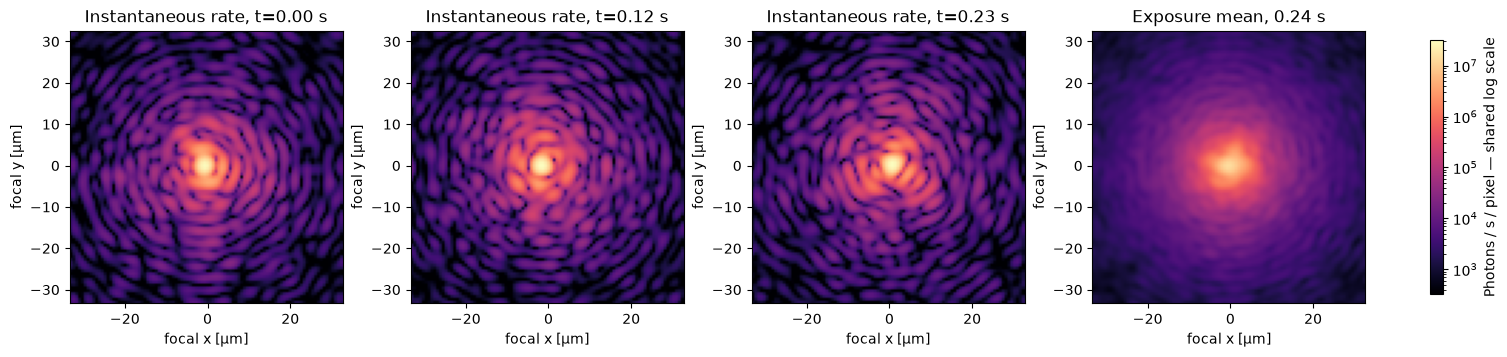

In [4]:
norm = LogNorm(vmin=float(rates.max())*1e-5, vmax=float(rates.max()))
fig,axes=plt.subplots(1,4,figsize=(15,3.5),constrained_layout=True)
for ax,i in zip(axes[:3],indices):
    im=ax.imshow(array(rates[i]),origin='lower',extent=extent(field.grid,1e-6),cmap='magma',norm=norm)
    ax.set_title(f'Instantaneous rate, t={i*dt:.2f} s')
im=axes[3].imshow(array(mean_rate),origin='lower',extent=extent(field.grid,1e-6),cmap='magma',norm=norm)
axes[3].set_title(f'Exposure mean, {T*dt:.2f} s')
for ax in axes: ax.set(xlabel='focal x [µm]',ylabel='focal y [µm]')
fig.colorbar(im,ax=list(axes),label='Photons / s / pixel — shared log scale',shrink=.8)
plt.show()

## 4. Can the batch reproduce the explicit loop?

The first two images show raw integrated counts on identical scales. The third magnifies the signed numerical residual in its own units. The line cut checks the spatial profile, and the frame-by-frame curve checks complex amplitudes before any integration. A zero FFT residual is valid; it is not replaced with artificial noise.

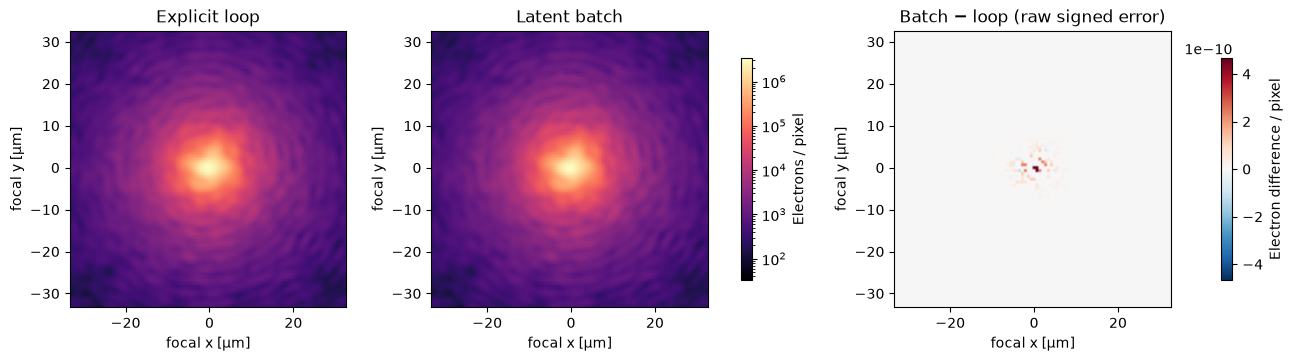

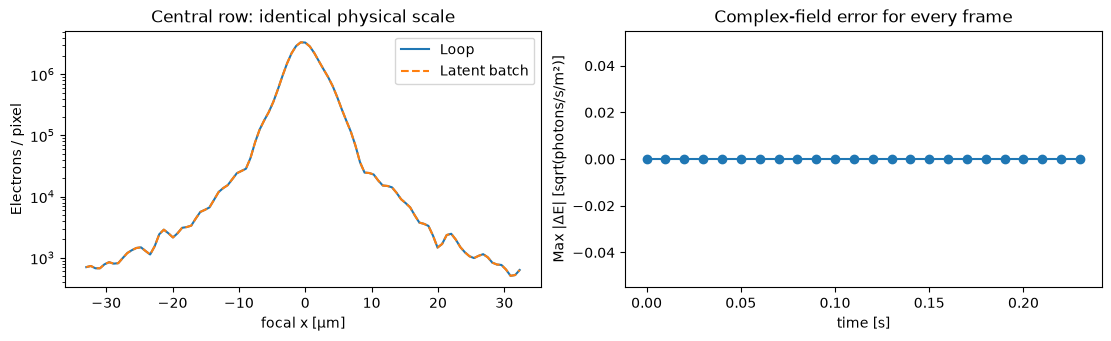

In [5]:
reference, actual = main['expected'], main['counts']
difference = actual-reference
bound=max(float(difference.abs().max()),np.finfo(float).tiny)
norm_counts=LogNorm(vmin=float(reference.max())*1e-5,vmax=float(reference.max()))
fig,axes=plt.subplots(1,3,figsize=(13,3.5),constrained_layout=True)
for ax,value,title in zip(axes[:2],[reference,actual],['Explicit loop','Latent batch']):
    im=ax.imshow(array(value),origin='lower',extent=extent(field.grid,1e-6),cmap='magma',norm=norm_counts)
    ax.set_title(title)
fig.colorbar(im,ax=list(axes[:2]),label='Electrons / pixel',shrink=.8)
im=axes[2].imshow(array(difference),origin='lower',extent=extent(field.grid,1e-6),cmap='RdBu_r',vmin=-bound,vmax=bound)
axes[2].set_title('Batch − loop (raw signed error)')
fig.colorbar(im,ax=axes[2],label='Electron difference / pixel',shrink=.8)
for ax in axes:ax.set(xlabel='focal x [µm]',ylabel='focal y [µm]')
plt.show()
fig,axes=plt.subplots(1,2,figsize=(11,3.3),constrained_layout=True)
y=field.grid.ny//2
axes[0].semilogy(array(field.grid.x/1e-6),array(reference[y]),label='Loop')
axes[0].semilogy(array(field.grid.x/1e-6),array(actual[y]),'--',label='Latent batch')
axes[0].set(xlabel='focal x [µm]',ylabel='Electrons / pixel',title='Central row: identical physical scale')
axes[0].legend()
per_sample=(field.complex_amplitude-main['loop']).abs().flatten(1).amax(1)
axes[1].plot(np.arange(T)*dt,array(per_sample),'o-')
axes[1].set(xlabel='time [s]',ylabel='Max |ΔE| [sqrt(photons/s/m²)]',title='Complex-field error for every frame')
plt.show()

## 5. How the exposure builds up

Each panel uses a prefix of the **same cube**, with the same colour limits. The table keeps raw cumulative electrons and reports the fraction within radius 1.22 λf/D. This finite focal window does not capture all transmitted flux. More samples need not improve every metric monotonically.

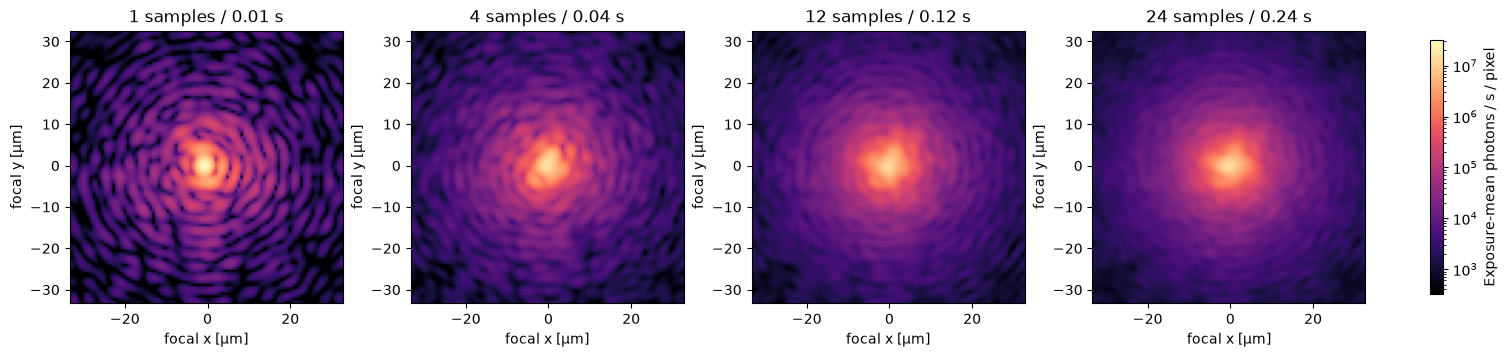

Samples,Exposure [s],Total electrons in window,Core fraction
1,0.01,9.022015e+06,0.6216
4,0.04,3.607376e+07,0.5666
12,0.12,1.082182e+08,0.4963
24,0.24,2.164394e+08,0.5079


In [6]:
prefixes=[1,4,12,T]
fig,axes=plt.subplots(1,4,figsize=(15,3.5),constrained_layout=True)
for ax,k in zip(axes,prefixes):
    prefix_rate=rates[:k].mean(0)
    im=ax.imshow(array(prefix_rate),origin='lower',extent=extent(field.grid,1e-6),cmap='magma',norm=norm)
    ax.set(title=f'{k} samples / {k*dt:.2f} s',xlabel='focal x [µm]',ylabel='focal y [µm]')
fig.colorbar(im,ax=list(axes),label='Exposure-mean photons / s / pixel',shrink=.8)
plt.show()
# Cumulative counts grow with duration; dividing by elapsed seconds is only
# for the rate comparison above. Detector validation uses raw counts.
core=(field.grid.meshgrid()[0]**2+field.grid.meshgrid()[1]**2)<(1.22*1.1e-6*2/diameter)**2
cumulative=(rates*dt).cumsum(0)
table(['Samples','Exposure [s]','Total electrons in window','Core fraction'],[
    [k,f'{k*dt:.2f}',f'{cumulative[k-1].sum():.6e}',f'{cumulative[k-1][core].sum()/cumulative[k-1].sum():.4f}']
    for k in prefixes])

## 6. Numerical evidence across optical chains

Absolute field errors have units sqrt(photons/s/m²); exposure and chunked errors are electrons/pixel (QE=1). RMS is sqrt(mean(|batch−reference|²)). Relative errors divide by the reference magnitude with a floating-point tiny guard; near-zero reference pixels can amplify that diagnostic. The assertions combine absolute and relative tolerances and never rescale an image. Each chain is compared against its own reference, not against a different propagation regime.

In [7]:
metric_rows=[]
for row in rows:
    for quantity in ['field','exposure','chunked']:
        e=row[quantity]
        metric_rows.append([row['case'],quantity,f"{e['max_absolute']:.3e}",f"{e['max_relative']:.3e}",f"{e['rms']:.3e}"])
table(['Optical chain','Quantity','Max absolute','Max pointwise relative','RMS'],metric_rows)

Optical chain,Quantity,Max absolute,Max pointwise relative,RMS
FFT Fraunhofer,field,0.000e+00,0.000e+00,0.000e+00
FFT Fraunhofer,exposure,9.313e-10,2.220e-16,2.704e-11
FFT Fraunhofer,chunked,1.863e-09,4.883e-16,6.451e-11
MFT monochromatic Fraunhofer,field,0.000e+00,0.000e+00,0.000e+00
MFT monochromatic Fraunhofer,exposure,4.657e-10,2.219e-16,1.187e-11
MFT monochromatic Fraunhofer,chunked,9.313e-10,6.098e-16,2.633e-11
MFT polychromatic Fraunhofer,field,0.000e+00,0.000e+00,0.000e+00
MFT polychromatic Fraunhofer,exposure,4.657e-10,2.218e-16,1.606e-11
MFT polychromatic Fraunhofer,chunked,9.313e-10,5.967e-16,2.287e-11
MFT Fresnel,field,0.000e+00,0.000e+00,0.000e+00


### Incoherent exposure is not a coherent average

Two equal fields with opposite phase cancel when amplitudes are averaged.
Their intensities still add at the detector. This deliberately simple check
also catches an accidental second exposure-time multiplier.


In [8]:
two_times = FieldDimension('time', 2, unit='s',
                           integration_weights=torch.full((2,), .01, dtype=dtype))
opposite = mono.expand_dimension(two_times) * torch.tensor([1., -1.], dtype=dtype)[:, None, None, None]
assert opposite.coherent_mean('time').intensity().sum() == 0
expected = mono.intensity().sum(-3)*.02*grid.dx*grid.dy
counts = Detector(grid, exposure_time=.02).acquire(opposite, integrate_over='time')
torch.testing.assert_close(counts, expected, rtol=1e-11, atol=1e-8)
assert counts.sum() > 0
print('Opposite-phase exposure errors:', errors(counts, expected))


Opposite-phase exposure errors: {'max_absolute': 0.0, 'max_relative': 0.0, 'rms': 0.0}


## Correlated temporal buffers

An injected, seeded translating backend tests the adapter without requiring the optional FATMOSS dependency. The real backend remains covered by optional tutorial 10. Both chunk partitions must integrate the same exposure, and `advance=False` must preserve selected time.

In [9]:
# Injected backend: optional FATMOSS installation is not needed for this check.
import numpy as np

class TranslatingScreen:
    def __init__(self, seed=51):
        self.phase = np.random.default_rng(seed).uniform(0, 2*np.pi)
    def GetScreenByTimestep(self, timestep):
        x = np.arange(grid.nx)[:, None] - .37*timestep  # non-integer pixel displacement
        y = np.arange(grid.nx)[None, :]
        return 80*np.cos(2*np.pi*x/grid.nx + self.phase) * np.cos(2*np.pi*y/grid.nx)  # nm, (x,y)

backend = TranslatingScreen()
model = FatmossAtmosphereModel(grid, backend, time_step=.01)
# Record the exact cube consumed by apply_buffer; the reference never resamples.
sampled_cubes = []
sequence_opd = model.sequence_opd

def record_sequence(*args, **kwargs):
    cube = sequence_opd(*args, **kwargs)
    sampled_cubes.append(cube.clone())
    return cube

model.sequence_opd = record_sequence
atmosphere = Atmosphere(grid, model)
buffer = atmosphere.apply_buffer(mono, 8, advance=False)
assert model.current_time == 0
propagator = FFTPropagator(2.)
with torch.no_grad():
    propagated = propagator.apply(buffer)
    cube = sampled_cubes[0]
    loop = torch.stack([propagator.apply(mono.apply_opd(screen)).complex_amplitude for screen in cube])
    torch.testing.assert_close(propagated.complex_amplitude, loop)
    detector = Detector(propagated.grid, exposure_time=.08)
    expected = (loop.abs().square().sum(-3)*.01).sum(0)*propagated.grid.dx*propagated.grid.dy
    integrated = detector.acquire(propagated, integrate_over='time')
    torch.testing.assert_close(integrated, expected, rtol=1e-11, atol=1e-8)
    partitions = []
    for lengths in ([1, 3, 4], [4, 4]):
        model.seek(0)
        accumulator = ExposureAccumulator(detector)
        for length in lengths:
            accumulator.add(propagator.apply(atmosphere.apply_buffer(mono, length)))
        result = accumulator.finish()
        torch.testing.assert_close(result, expected)
        assert model.current_time == .08
        partitions.append({'lengths': lengths, **errors(result, expected)})
table(['Injected backend comparison','Max absolute','Max relative','RMS'], [[label, *[f'{v:.3e}' for v in errors(a,b).values()]] for label,a,b in [('Complex field',propagated.complex_amplitude,loop),('Integrated counts',integrated,expected)]])
table(['Chunk lengths','Max absolute','Max relative','RMS'],[[str(p['lengths']),f"{p['max_absolute']:.3e}",f"{p['max_relative']:.3e}",f"{p['rms']:.3e}"] for p in partitions])

# Scalar replay and same-seed replay are separate from the optical comparison.
scalar_cube = torch.stack([model.opd_at(t*.01) for t in range(8)])
torch.testing.assert_close(scalar_cube, cube, rtol=0, atol=0)
replay_model = FatmossAtmosphereModel(grid, TranslatingScreen(seed=51), time_step=.01)
torch.testing.assert_close(replay_model.sequence_opd(8, advance=False), cube, rtol=0, atol=0)
from fiatlux.optics.turbulence_validation import temporal_autocorrelation
torch.testing.assert_close(temporal_autocorrelation(scalar_cube),
                           temporal_autocorrelation(cube), rtol=0, atol=0)
assert model.current_time == .08  # Replay queries did not advance the selected time.


Injected backend comparison,Max absolute,Max relative,RMS
Complex field,0.000e+00,0.000e+00,0.000e+00
Integrated counts,2.328e-10,2.220e-16,4.044e-12


Chunk lengths,Max absolute,Max relative,RMS
"[1, 3, 4]",1.863e-09,5.322e-16,4.738e-11
"[4, 4]",1.863e-09,5.322e-16,3.121e-11


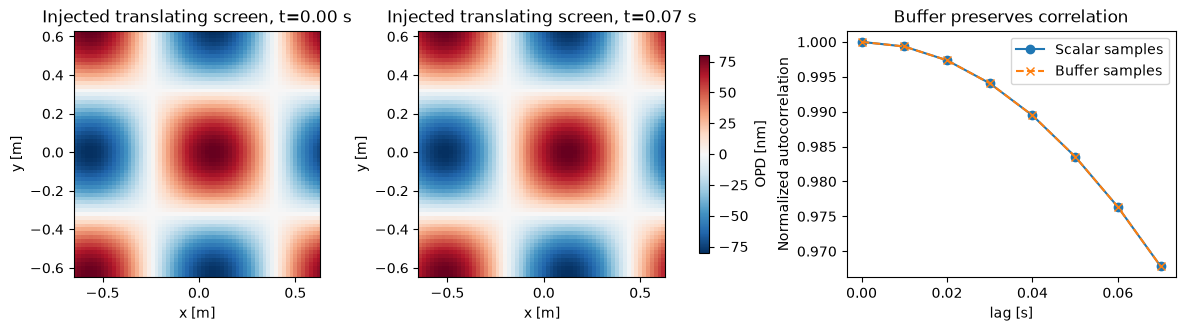

In [10]:
fig,axes=plt.subplots(1,3,figsize=(12,3.2),constrained_layout=True)
for ax,i in zip(axes[:2],[0,7]):
    im=ax.imshow(array(cube[i]*1e9),origin='lower',extent=extent(grid),cmap='RdBu_r',vmin=-80,vmax=80)
    ax.set(title=f'Injected translating screen, t={i*.01:.2f} s',xlabel='x [m]',ylabel='y [m]')
fig.colorbar(im,ax=list(axes[:2]),label='OPD [nm]',shrink=.8)
lags=np.arange(8)*.01
axes[2].plot(lags,array(temporal_autocorrelation(scalar_cube)),'o-',label='Scalar samples')
axes[2].plot(lags,array(temporal_autocorrelation(cube)),'x--',label='Buffer samples')
axes[2].set(xlabel='lag [s]',ylabel='Normalized autocorrelation',title='Buffer preserves correlation')
axes[2].legend()
plt.show()

## Scope and interpretation

The figures establish equivalence for the frozen samples and supported chains, not statistical convergence of an infinite exposure. The correlated example is a deterministic injected adapter backend, **not a validation of real FATMOSS physics**; real FATMOSS remains optional. FFT is monochromatic, latent Shack–Hartmann inputs are explicitly rejected, and time-dependent DM commands are not implemented.

Chunk accumulation combines expected intensity before one detector readout. Full gradient tracking retains the history; detached accumulation can bound retained graph memory. Timing belongs in the separate benchmark, not this scientific demonstration.